Navn: Milad Tootoonchi
# Minste Kvadraters Metode - AAPL stock data  
Datasettet består av historiske ukentlige AAPL-aksjepriser, inkludert dato, åpningskurs, høyeste- og laveste kurs,  
sluttkurs og volum (antall omsatte aksjer).  
Det historiske dataet vil ha dato fra 09. september 1984 til 17. november 2025.  
Dataen er hentet fra yahoo finance og problemstillingen er å undersøke om en lineær regresjonsmodell  
basert på minste-kvadraters metode kan brukes til å predikere kursens trend.

## Imports

In [22]:
using Downloads
using CSV
using DataFrames
using Dates
using Statistics
using Plots
using LinearAlgebra
using Random

# Laster ned CSV filen
url = "https://stooq.com/q/d/l/?s=aapl.us&i=w"
Downloads.download(url, "AAPL_weekly.csv")

"AAPL_weekly.csv"

## Load Data og Data-utforskning

In [23]:
df = CSV.read("AAPL_weekly.csv", DataFrame)

first(df, 5)

Row,Date,Open,High,Low,Close,Volume
,Date,Float64,Float64,Float64,Float64,Int64
1,1984-09-09,0.0996047,0.100827,0.0984022,0.0996047,98811715
2,1984-09-16,0.0996047,0.107124,0.0972099,0.10472,954568288
3,1984-09-23,0.10744,0.108938,0.0996047,0.100827,667384362
4,1984-09-30,0.100827,0.102304,0.0923906,0.0941941,826115858
5,1984-10-07,0.0939084,0.0959978,0.0920853,0.0932972,664008250


In [24]:
# Konverter dato til riktig type og sorter
df.Date = Date.(df.Date)
sort!(df, :Date)

describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Date,,1984-09-09,,2025-11-16,0,Date
2,Open,29.7895,0.0556708,1.14194,270.42,0,Float64
3,High,30.6699,0.0568732,1.1997,277.32,0,Float64
4,Low,29.0744,0.0541729,1.10982,267.455,0,Float64
5,Close,29.9393,0.0547743,1.15089,272.41,0,Float64
6,Volume,1.85801e9,98811715,1.25177e9,13343150239,0,Int64


In [45]:
# Sjekker for NA-verdier
any(ismissing, eachrow(df))

false

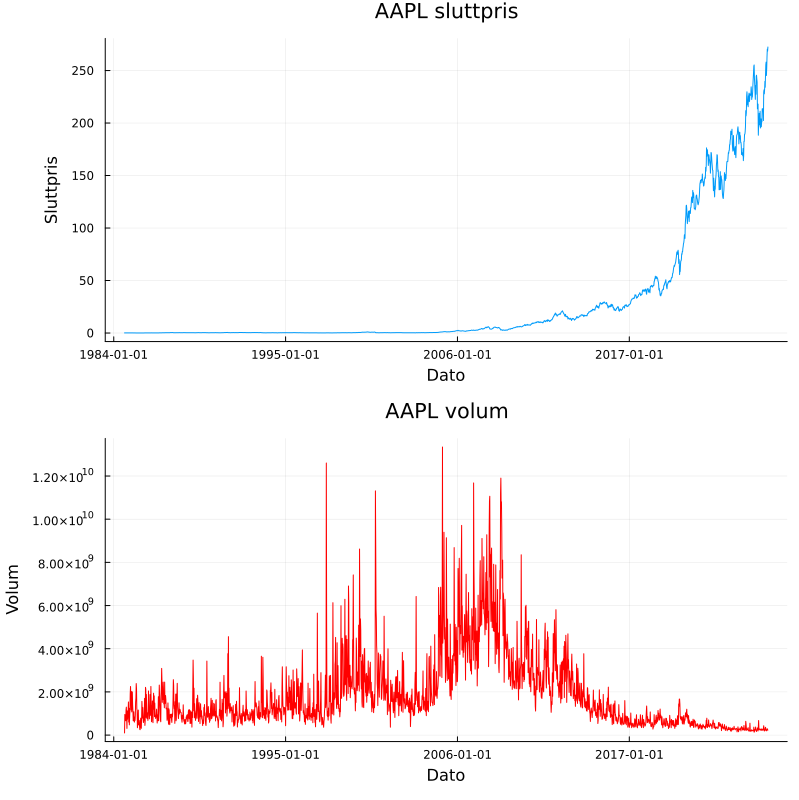

In [42]:
# Plotter sluttpris over tid
sluttpris = plot(df.Date, df.Close, title = "AAPL sluttpris", 
                xlabel = "Dato", ylabel = "Sluttpris", legend = false)

# Plotter volum
volum = plot(df.Date, df.Volume, title = "AAPL volum", 
            xlabel = "Dato", ylabel = "Volum", legend = false, color = :red)

plot(sluttpris, volum, layout = (2, 1), size = (800, 800))


## Feature Engineering og mer datautforskning

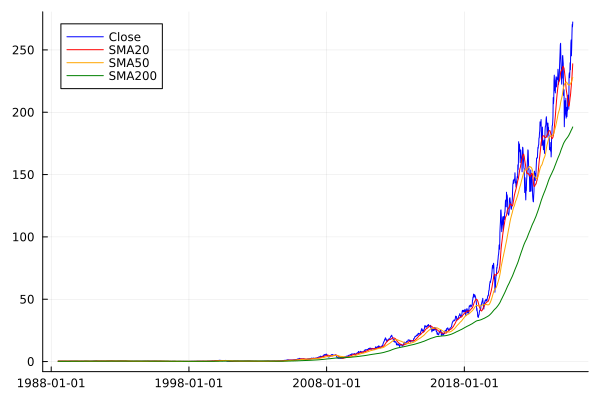

In [49]:
# Simple moving average
sma(x, n) = [i < n ? missing : mean(x[i-n+1:i]) for i in 1:length(x)]

df.SMA20  = sma(df.Close, 20)
df.SMA50  = sma(df.Close, 50)
df.SMA200 = sma(df.Close, 200)

# De første 1999 radene får NA-verdier ettersom de mangler nok datapunkter
df = dropmissing(df)

plot(df.Date, df.Close, label = "Close", color=:blue)
plot!(df.Date, df.SMA20, label = "SMA20", color=:red)
plot!(df.Date, df.SMA50, label = "SMA50", color=:orange)
plot!(df.Date, df.SMA200, label = "SMA200", color=:green)

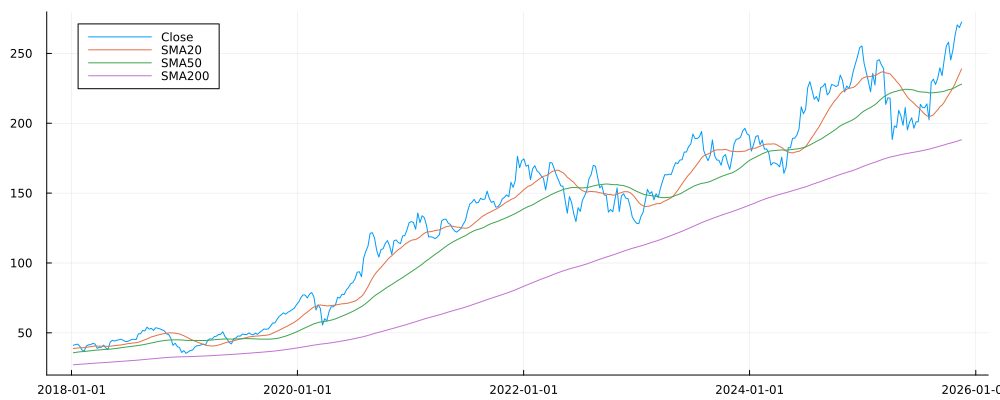

In [55]:
# Nærmere utforsking når prisene stiger kraftig
df_2018 = df[df.Date .>= Date(2018, 1, 1), :]

plot(df_2018.Date, df_2018.Close, label = "Close")
plot!(df_2018.Date, df_2018.SMA20, label = "SMA20")
plot!(df_2018.Date, df_2018.SMA50, label = "SMA50")
plot!(df_2018.Date, df_2018.SMA200, label = "SMA200")
plot!(size = (1000, 400))